## Preamble

In [38]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

In [39]:
ε_r=12; μ_r=1; σ=0.006

v = 299/np.sqrt(ε_r*μ_r)
print('v =',v) #86 m/μs

fpeak = 400 #MHz

λmin = v/fpeak/2
print('λmin =',λmin) #0.108 m

h=0.02 #m

nz=201; nx=201
nzsnap=nz+48
nxsnap=nx+48
nsnap=51
print(f'length = {(nz-1)*h} m')

dt_CFL = 0.6*h/v
print('dt_CFL =',dt_CFL) #μs
dt = 0.0001 #μs

nt = 700
t=np.arange(0,nt*dt,dt)

v = 86.31386524384905
λmin = 0.10789233155481132
length = 4.0 m
dt_CFL = 0.000139027489570746


In [40]:
def epsmu2cel(eps,mu):
    return 299/np.sqrt(eps*mu)

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

ntr=201
def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[24:24+nz,24:24+nx,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

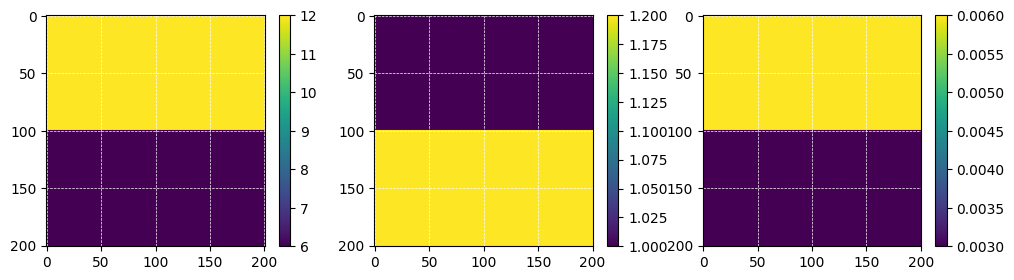

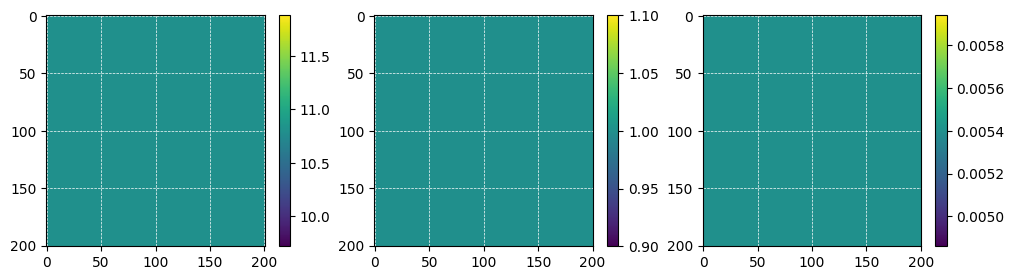

In [67]:
# True
eps_r = ε_r*np.ones((nz,nx)); eps_r[nz//2:,:]=ε_r/2
mu_r  = μ_r*np.ones((nz,nx));  mu_r[nz//2:,:]=1.2
sgma  = σ  *np.ones((nz,nx));  sgma[nz//2:,:]=σ/2
true=np.concatenate((eps_r,mu_r,sgma),axis=1)
true.T.astype('float32').tofile('true')

#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(true[:,:nx])
plt.subplot(1,3,2); imshow(true[:,nx:2*nx])
plt.subplot(1,3,3); imshow(true[:,2*nx:])

# Initial
eps_r = 0.9*ε_r*np.ones((nz,nx))
# mu_r  = 0.9*μ_r*np.ones((nz,nx))  #diamagnetic materials
mu_r  = μ_r*np.ones((nz,nx))
sgma  = 0.9*σ  *np.ones((nz,nx))
init=np.concatenate((eps_r,mu_r,sgma),axis=1)
init.T.astype('float32').tofile('init')

#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(init[:,:nx])
plt.subplot(1,3,2); imshow(init[:,nx:2*nx])
plt.subplot(1,3,3); imshow(init[:,2*nx:])

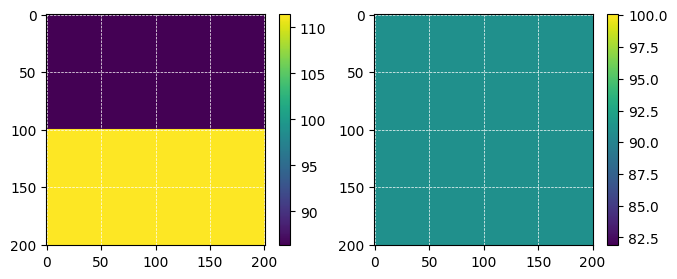

In [68]:
#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(epsmu2cel(true[:,:nx],true[:,nx:2*nx]))
plt.subplot(1,3,2); imshow(epsmu2cel(init[:,:nx],init[:,nx:2*nx]))

In [69]:
print(epsmu2cel(true[:,:nx],true[:,nx:2*nx])[1,1])
print(epsmu2cel(init[:,:nx],init[:,nx:2*nx])[1,1])

86.31386524384905
90.98280260780258


In [70]:
%%writefile setup_default

MODEL_SIZE              '201   201   1'
MODEL_SPACING           '0.02 0.02   1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'eps_r mu_r sgma'
NAIRL                    0

ACQUI_GEOMETRY          spread
FS                      '1     1  0'
FR                      '1     0  0'
DR                      '0  0.02  0'
NR                       201
SU_SCALCO               -100

IF_HICKS                 F

SCOMP                    Ey
RCOMP                    Ey

NT                       700
DT                       0.0001
WAVELET_TYPE             ricker
FPEAK                    400

SNAPSHOT                'Hx Hz Ey'

### for inversion ###
FILE_DATA_PREFIX        'results_obs/Ru_Shot'

WEIGHTING               'none'

PARAMETER               'eps_r:6:12'

SMOOTHING               'none'
#PRECO         'z^0'

#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'

IF_USE_CHECKPOINT        F

Overwriting setup_default


## TE

### Ey-Ey

#### Obs & Syn data

In [75]:
!cp setup_default setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2176520 Jun 20 22:41 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/20/2026
System time: 22:41:41
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 

In [76]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 2176520 Jun 20 22:41 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/20/2026
System time: 22:41:57
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 

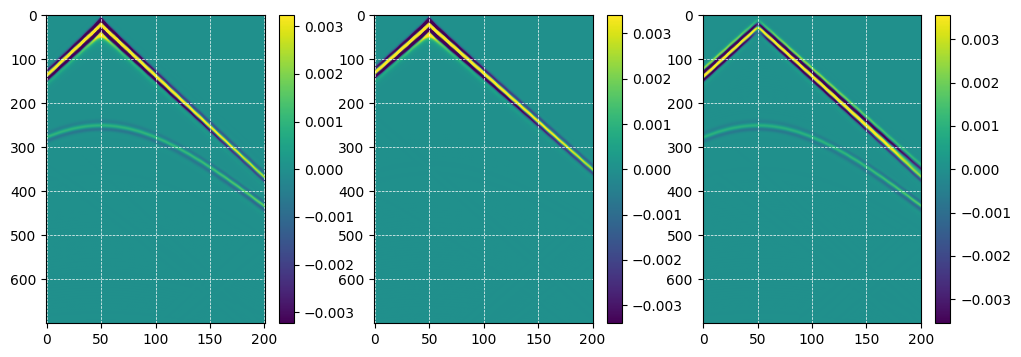

In [77]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_obs/Ru_Shot0001.su') \
                          -read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [83]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "ALPHAS      1 " >> setup
run(app='../../exe/GradientTest')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 joey joey 35 Jun 20 22:42 ../../exe/GradientTest -> gradienttest_TE_FDSG_O4_eps-mu-sgma
 Git Commit: cfd890f
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/20/2026
System time: 22:45:54
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vma

 it----         500
 fld_a minmax values:  -5.26389578E-16   4.02480093E-16
 fld_u minmax values:  -2.44740228E-09   2.71616063E-09
 Elapsed time to load boundary               2.84855366E-02
 Elapsed time to update stresses            0.491369724    
 Elapsed time to rm source stresses          6.67548180E-03
 Elapsed time to update velocities          0.490752459    
 Elapsed time to rm source velocities        3.74460220E-03
 Elapsed time ----------------------------
 Elapsed time to add adjsource stresses      4.29701805E-03
 Elapsed time to update adj stresses        0.476176977    
 Elapsed time to add adjsource velocities    1.17709637E-02
 Elapsed time to update adj velocities      0.391421318    
 Elapsed time to extract&write fields        0.00000000    
 Elapsed time to correlate                   7.76934624E-03
 Viewing the snapshots (if written) with SU ximage/xmovie:
 ximage < snap_rfield%*  n1=249 perc=99
 xmovie < snap_rfield%*  n1=249 n2=249 clip=?e-?? loop=2 title=%g


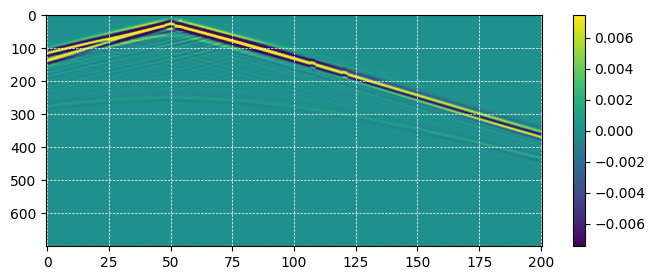

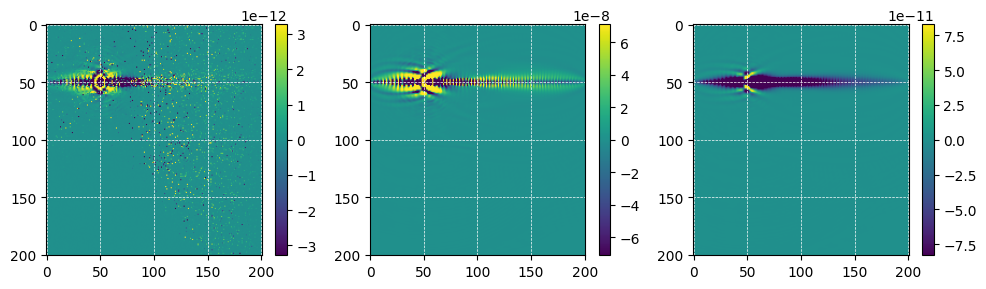

In [84]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz)) #gmu geps gsgma
plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(corr[:,:nx],perc=98)
plt.subplot(1,4,2); imshow(corr[:,nx:2*nx],perc=98)
plt.subplot(1,4,3); imshow(corr[:,2*nx:],perc=98)

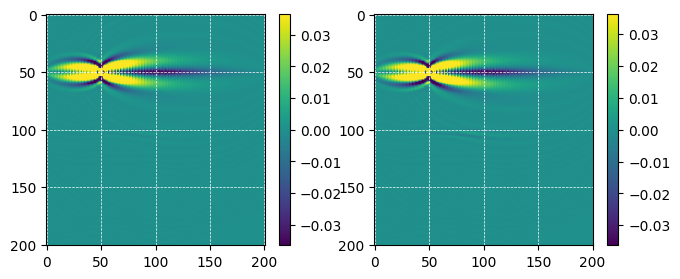

In [85]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results/qp0%g' ),perc=98)
plt.subplot(1,3,2); imshow(read('results/qp0%pg'),perc=98)

#### gradienttest_SH_FDSG_O4_velocities-density on gvs

In [26]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_SH_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

At line 539 of file m_field.f90
Fortran runtime warning: An array temporary was created for argument 'datain' of procedure 'resampler'
            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   35.0404625       35.0404701     -0.762939453      -1.20162237       1.57499051     F
 1st cond   9.99999975E-05   35.0403481       35.0404701      -1.22070312      -1.20162237      0.984369040     F
 1st cond   1.00000005E-03   35.0392380       35.0404701      -1.23214722      -1.20162237      0.975226283     F
 1st cond   9.99999978E-03   35.0283089       35.0404701      -1.21612549      -1.20162237      0.988074303     F
 1st cond  0.100000001       34.9198189       35.0404701      -1.20651245      -1.20162237      0.995946944     F
 1st cond   1.00000000       33.9011154       35.0404701      -1.13935471      -1.20162237       1.05465174     F


In [27]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_SH_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   35.0404892       35.0404778      -1.14440918      -1.20162320       1.04999435     F
 1st cond  -9.99999975E-05   35.0405655       35.0404778     -0.877380371      -1.20162320       1.36955786     F
 1st cond  -1.00000005E-03   35.0415421       35.0404778      -1.06430054      -1.20162320       1.12902617     F
 1st cond  -9.99999978E-03   35.0524635       35.0404778      -1.19857788      -1.20162320       1.00254083     F
 1st cond -0.100000001       35.1609917       35.0404778      -1.20513916      -1.20162320      0.997082531     F
 1st cond  -1.00000000       36.2592506       35.0404778      -1.21877289      -1.20162320      0.985928714     F


#### gradienttest_SH_FDSG_O4_velocities-density on grho

In [29]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "PARAMETER    'rho:500:2000'" >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_SH_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   22.5875778       22.5875816     -0.381469727     -0.310118765      0.812957764     T
 1st cond   9.99999975E-05   22.5875530       22.5875816     -0.286102295     -0.310118765       1.08394361     T
 1st cond   1.00000005E-03   22.5872765       22.5875816     -0.305175781     -0.310118765       1.01619720     T
 1st cond   9.99999978E-03   22.5846214       22.5875816     -0.296020508     -0.310118765       1.04762590     T
 1st cond  0.100000001       22.5586109       22.5875816     -0.289707184     -0.310118765       1.07045591     T
 1st cond   1.00000000       22.3115158       22.5875816     -0.276065826     -0.310118765       1.12335074     T


In [30]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "PARAMETER    'rho:500:2000'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_SH_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   22.5875835       22.5875816     -0.190734863     -0.310118765       1.62591553     F
 1st cond  -9.99999975E-05   22.5875988       22.5875816     -0.171661377     -0.310118765       1.80657279     F
 1st cond  -1.00000005E-03   22.5878525       22.5875816     -0.270843506     -0.310118765       1.14501095     F
 1st cond  -9.99999978E-03   22.5904236       22.5875816     -0.284194946     -0.310118765       1.09121847     F
 1st cond -0.100000001       22.6167164       22.5875816     -0.291347504     -0.310118765       1.06442916     F
 1st cond  -1.00000000       22.8905983       22.5875816     -0.303016663     -0.310118765       1.02343798     F
